In [66]:
print("Shape:", df.shape)

Shape: (9977, 13)


In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   str    
 1   Segment       9977 non-null   str    
 2   Country       9977 non-null   str    
 3   City          9977 non-null   str    
 4   State         9977 non-null   str    
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   str    
 7   Category      9977 non-null   str    
 8   Sub-Category  9977 non-null   str    
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1.1 MB


In [68]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [69]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [70]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [71]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [72]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [73]:
df = df.drop_duplicates()

In [74]:
print(df.shape)
print(df.duplicated().sum())

(9977, 13)
0


In [75]:
df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [76]:
df["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [77]:
df["Region"].unique()

<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

In [78]:
df["Segment"].unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [79]:
df["Category"].value_counts()

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

In [80]:
df["Region"].value_counts()

Region
West       3193
East       2845
Central    2319
South      1620
Name: count, dtype: int64

In [81]:
df["Segment"].value_counts()

Segment
Consumer       5183
Corporate      3015
Home Office    1779
Name: count, dtype: int64

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

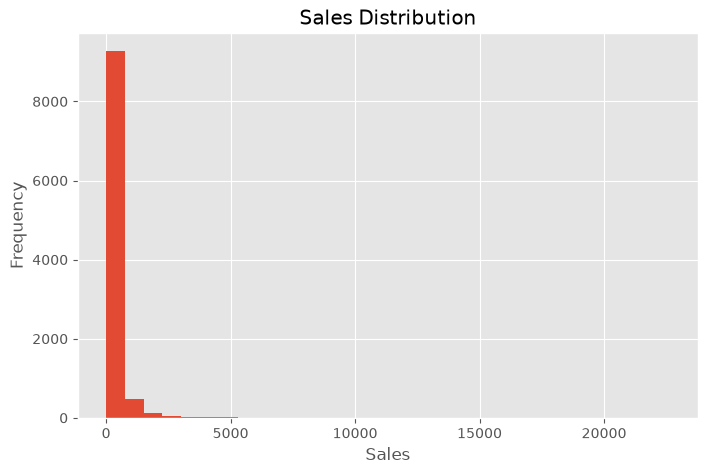

In [95]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

C:\Users\Ravi kumar\AppData\Local\Temp\ipykernel_9416\3080089289.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Sales"], vert=False)


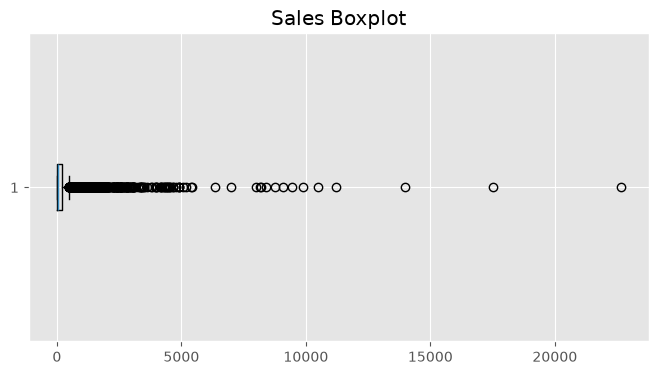

In [96]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Sales"], vert=False)

plt.title("Sales Boxplot")

plt.show()

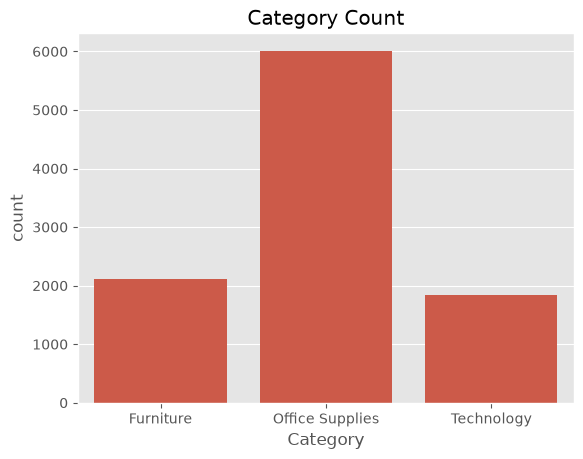

In [97]:
sns.countplot(data=df, x="Category")

plt.title("Category Count")

plt.show()

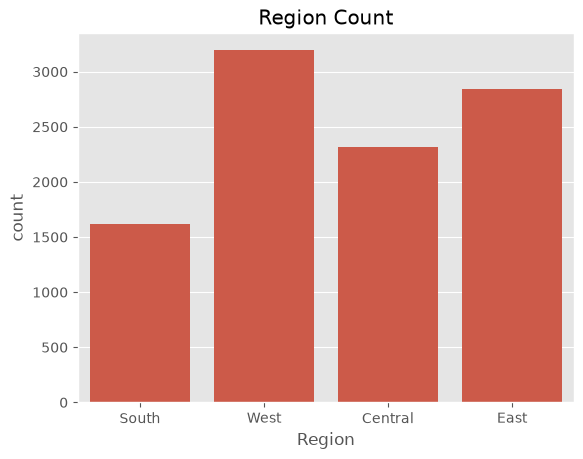

In [98]:
sns.countplot(data=df, x="Region")

plt.title("Region Count")

plt.show()

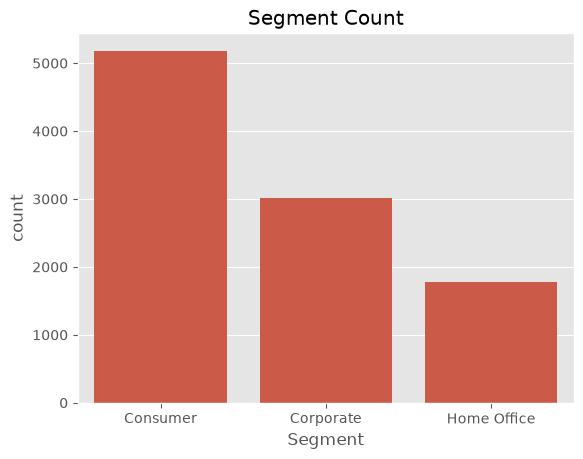

In [99]:
sns.countplot(data=df, x="Segment")

plt.title("Segment Count")

plt.show()

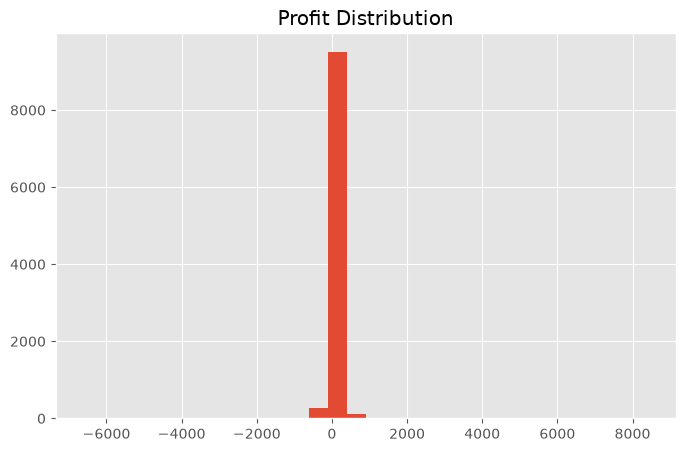

In [100]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=30)

plt.title("Profit Distribution")

plt.show()

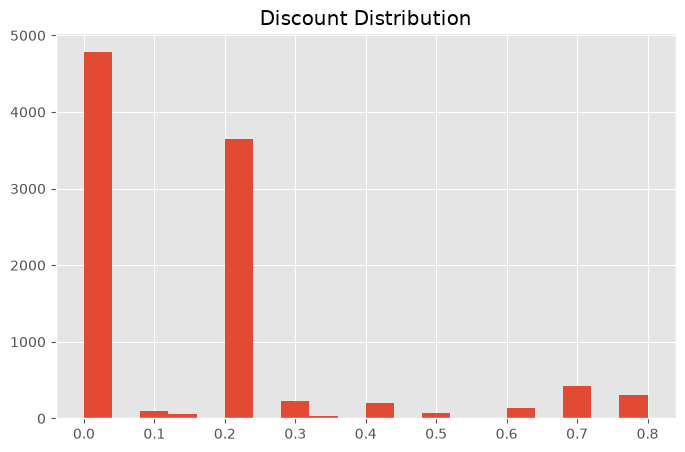

In [101]:
plt.figure(figsize=(8,5))

plt.hist(df["Discount"], bins=20)

plt.title("Discount Distribution")

plt.show()

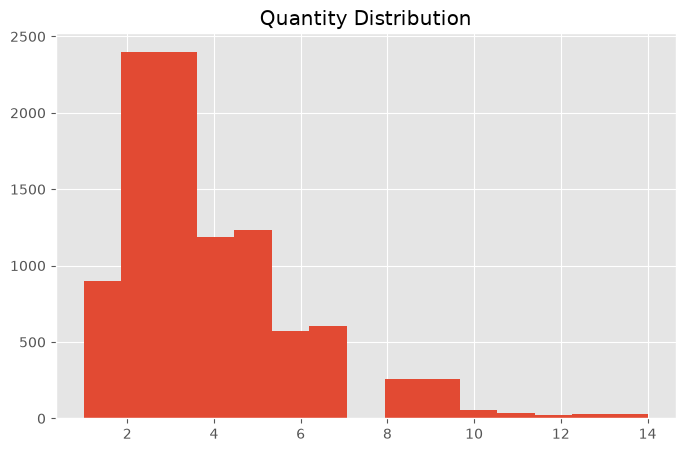

In [102]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=15)

plt.title("Quantity Distribution")

plt.show()

In [103]:
df[["Sales","Profit","Quantity","Discount"]].skew()

Sales       12.963770
Profit       7.554748
Quantity     1.276709
Discount     1.683386
dtype: float64

In [104]:
df[["Sales","Profit","Quantity","Discount"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9977.0,230.148902,623.721409,0.444,17.3000,54.816,209.970,22638.480
Profit,9977.0,28.690130,234.457840,-6599.978,1.7262,8.671,29.372,8399.976
Quantity,9977.0,3.790719,2.226657,1.000,2.0000,3.000,5.000,14.000
Discount,9977.0,0.156278,0.206455,0.000,0.0000,0.200,0.200,0.800


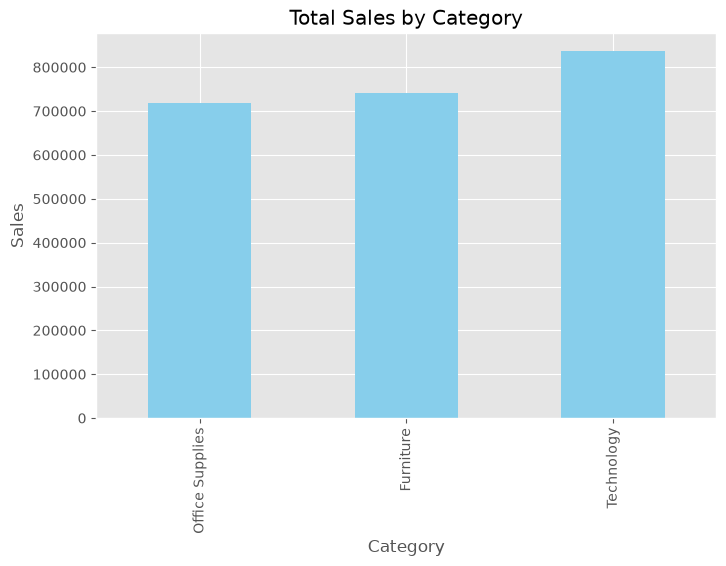

In [105]:
plt.figure(figsize=(8,5))

category_sales = df.groupby("Category")["Sales"].sum().sort_values()

category_sales.plot(kind="bar", color="skyblue")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

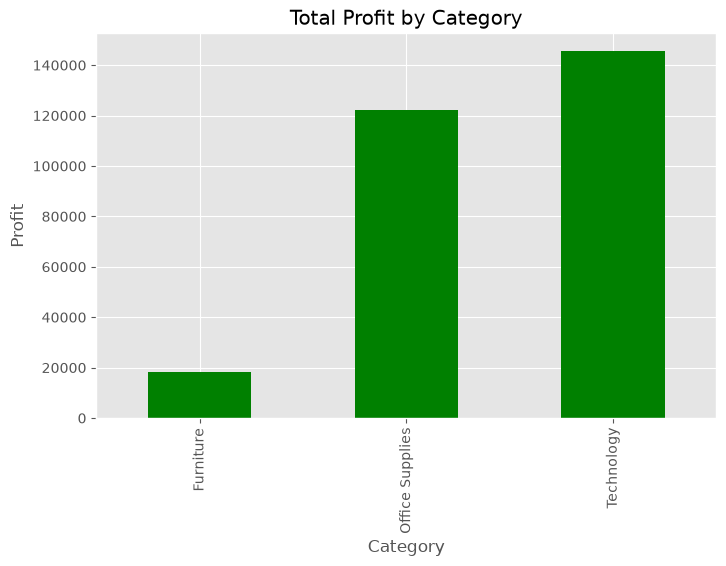

In [106]:
plt.figure(figsize=(8,5))

category_profit = df.groupby("Category")["Profit"].sum().sort_values()

category_profit.plot(kind="bar", color="green")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

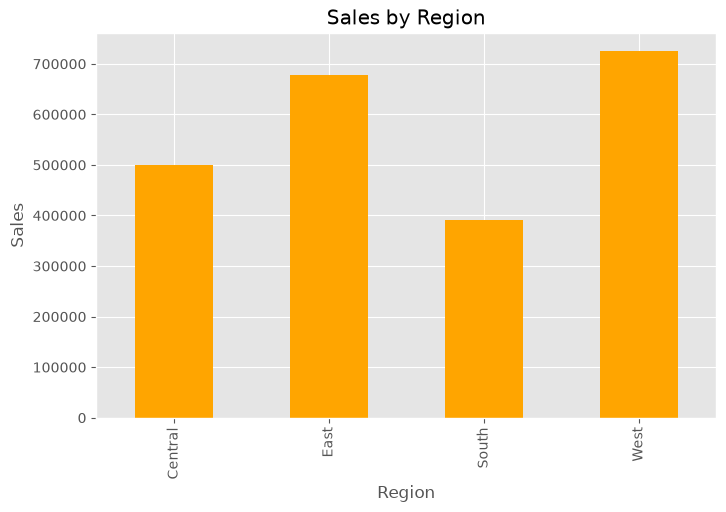

In [107]:
plt.figure(figsize=(8,5))

region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar", color="orange")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

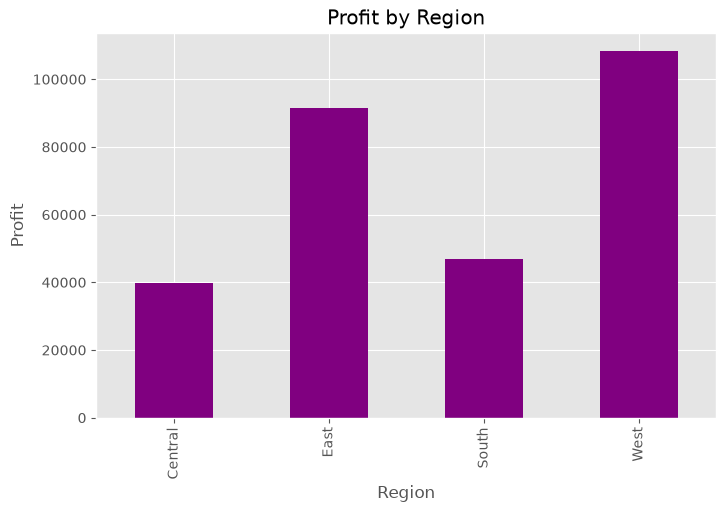

In [108]:
plt.figure(figsize=(8,5))

region_profit = df.groupby("Region")["Profit"].sum()

region_profit.plot(kind="bar", color="purple")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

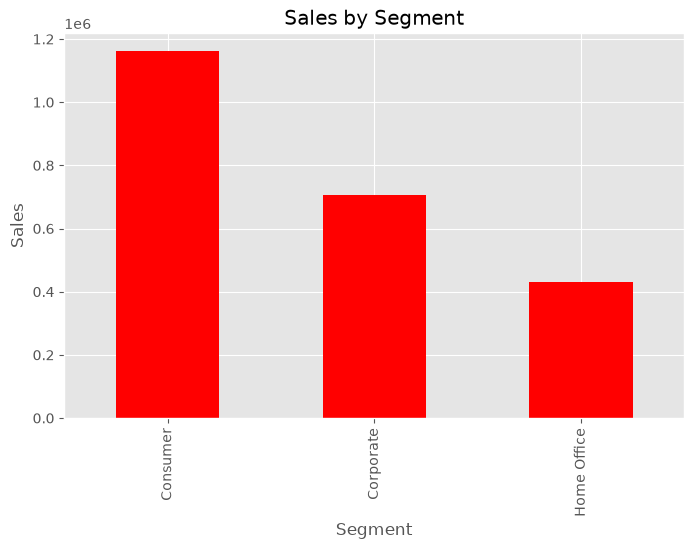

In [109]:
plt.figure(figsize=(8,5))

segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="bar", color="red")

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()

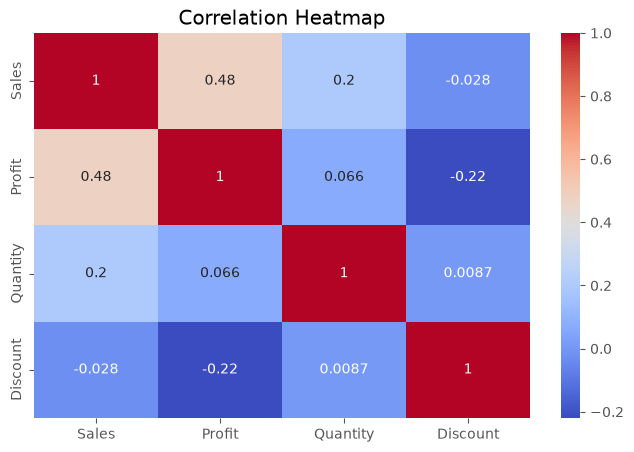

In [110]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Sales","Profit","Quantity","Discount"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

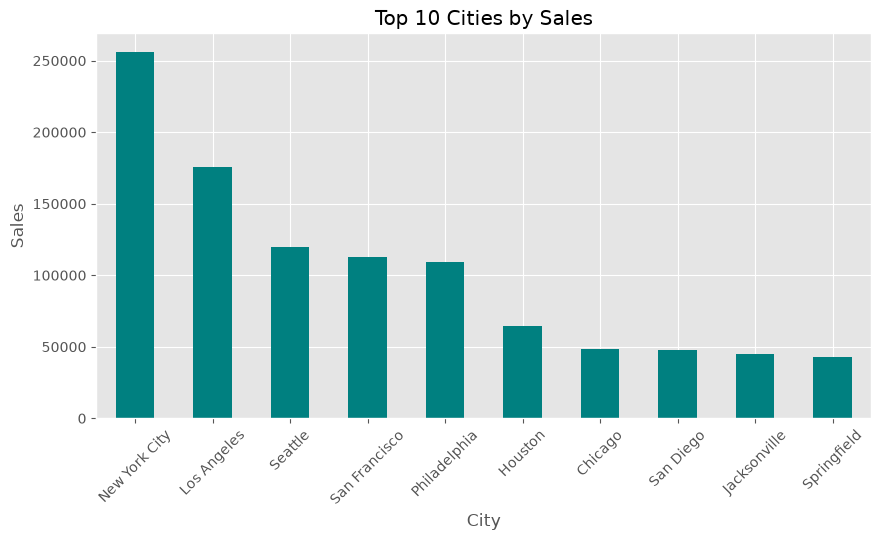

In [117]:
top_cities = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar", color="teal")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

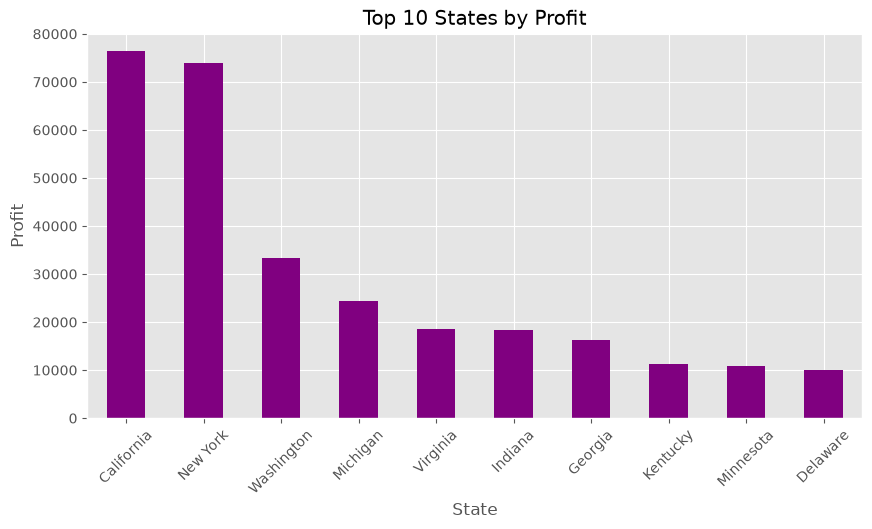

In [118]:
top_states = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar", color="purple")

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

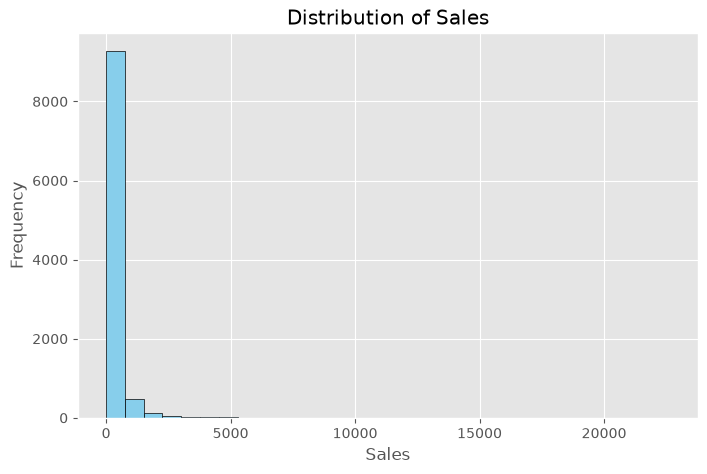

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30, color="skyblue", edgecolor="black")

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

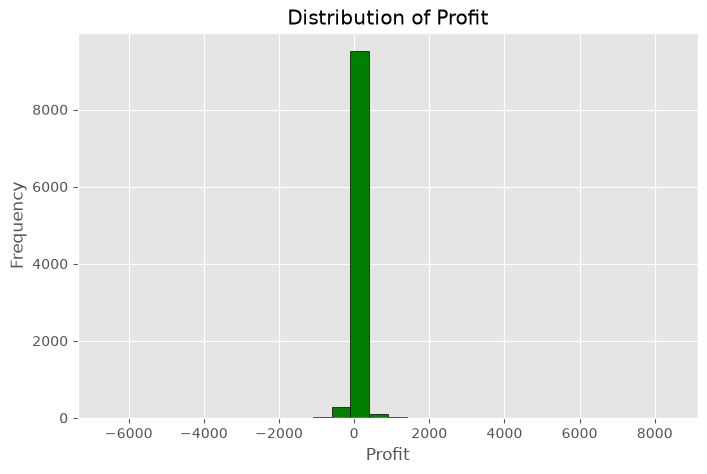

In [120]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=30, color="green", edgecolor="black")

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

C:\Users\Ravi kumar\AppData\Local\Temp\ipykernel_9416\1477070741.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Sales"], vert=False)


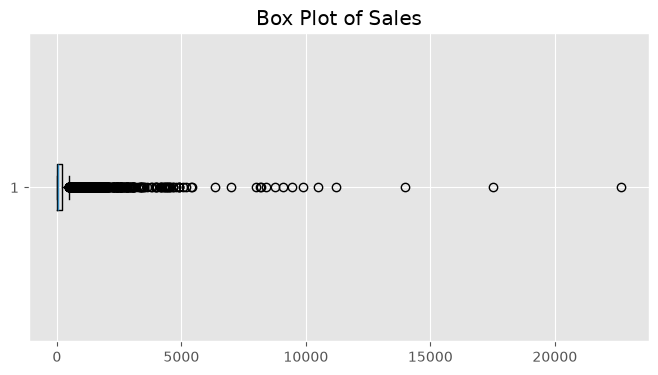

In [121]:
plt.figure(figsize=(8,4))

plt.boxplot(df["Sales"], vert=False)

plt.title("Box Plot of Sales")

plt.show()

C:\Users\Ravi kumar\AppData\Local\Temp\ipykernel_9416\3380014904.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Profit"], vert=False)


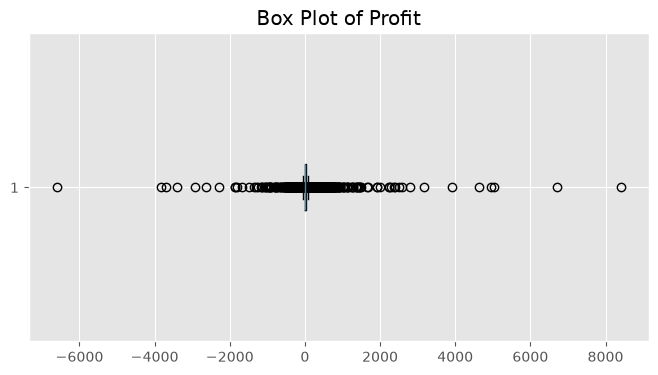

In [122]:
plt.figure(figsize=(8,4))

plt.boxplot(df["Profit"], vert=False)

plt.title("Box Plot of Profit")

plt.show()

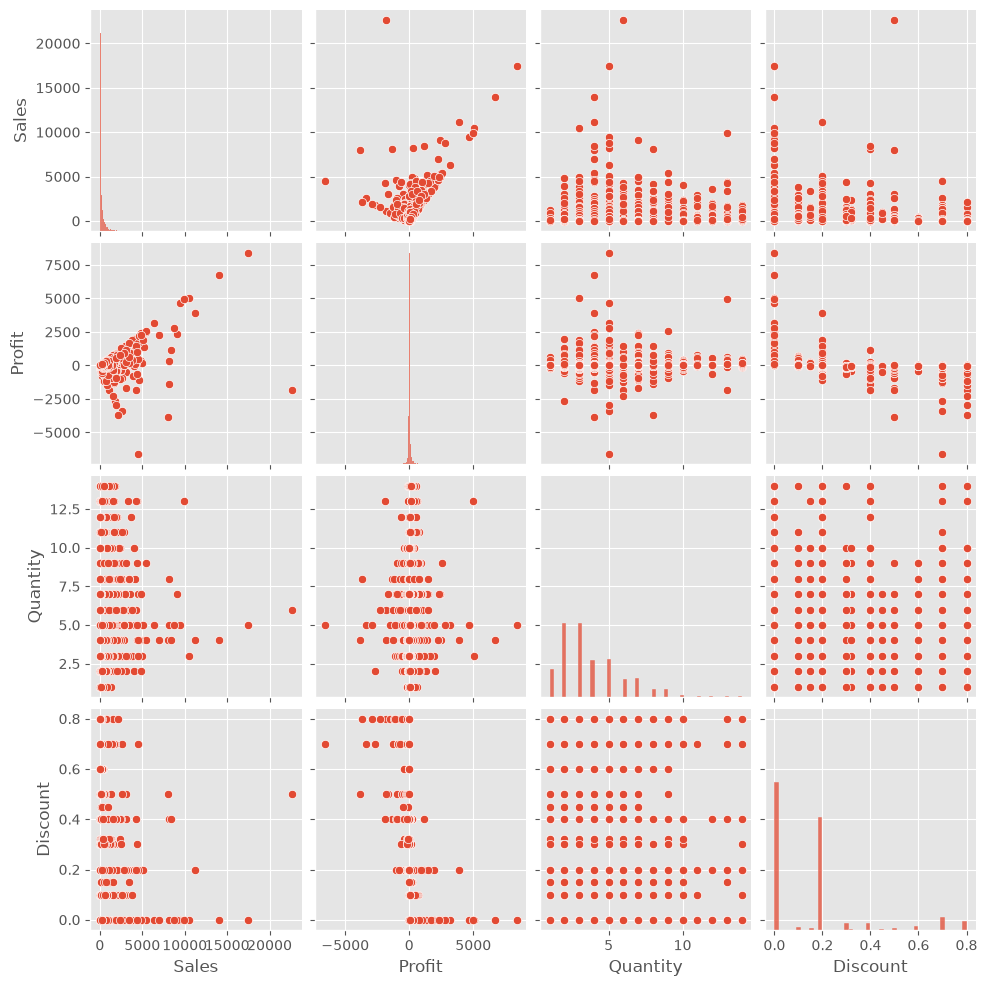

In [123]:
import seaborn as sns

sns.pairplot(
    df[["Sales","Profit","Quantity","Discount"]]
)

plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x28fa8f56120>,
 'caps': [<matplotlib.lines.Line2D at 0x28fa8f563c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x28fa8f55fd0>],
 'medians': [<matplotlib.lines.Line2D at 0x28fa8f56660>],
 'fliers': [<matplotlib.lines.Line2D at 0x28fa8f567b0>],
 'means': []}

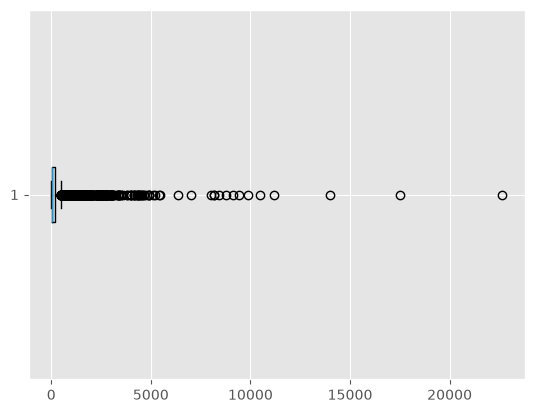

In [124]:
plt.boxplot(df["Sales"], orientation="horizontal")

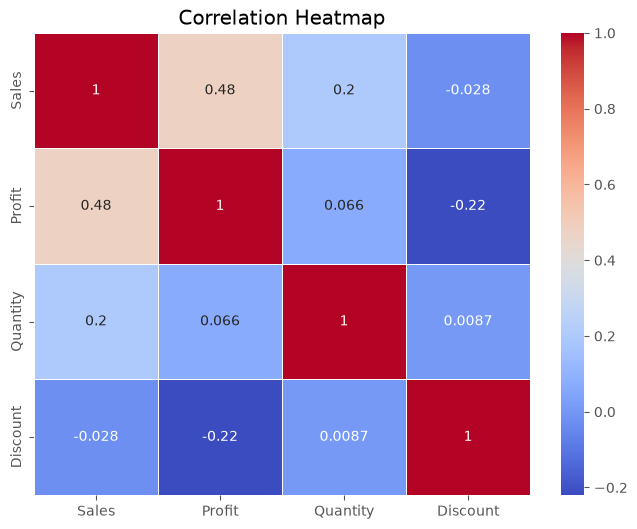

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Sales","Profit","Quantity","Discount"]].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Project updated